In [1]:
import os, urllib, shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime 
from sklearn import metrics
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

from sklearn.tree import DecisionTreeClassifier

import xgboost as xgb
from sklearn import svm
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression


import warnings
warnings.filterwarnings('ignore')
# Ref: https://github.com/bnsreenu/python_for_microscopists/blob/master/198_Boruta_feature_selection_breast_cancer.py

In [2]:
data_dir = '/media/josh/wd/data/ucsc_xena_data'
out_dir = '/media/josh/wd/data/tcga_data'


In [3]:
# rna = pd.read_csv(f'{data_dir}/tcga_RSEM_gene_tpm.gz', compression='gzip', header=0, sep='\t', index_col= 0)
# rna.to_parquet(f'{data_dir}/tcga_RSEM_gene_tpm.parquet.gzip', compression='gzip', index = True)

rna = pd.read_parquet(f'{data_dir}/tcga_RSEM_gene_tpm.parquet.gzip')
# rna.to_parquet(f'{data_dir}/tcga_RSEM_gene_tpm.parquet.gzip', compression='gzip', index = True)



In [4]:
rna.iloc[0:3, 0:6]

,TCGA-19-1787-01,TCGA-S9-A7J2-01,TCGA-G3-A3CH-11,TCGA-EK-A2RE-01,TCGA-44-6778-01,TCGA-F4-6854-01
sample,,,,,,
ENSG00000242268.2,-9.9658,0.2998,-9.9658,-9.9658,-9.9658,-9.9658
ENSG00000259041.1,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658
ENSG00000270112.3,-3.8160,-3.0469,-9.9658,-9.9658,-5.5735,-9.9658


In [5]:
genes = pd.read_csv('/media/josh/wd/data/ensembl_hgnc/ensembl_ncbi_gene_ID.from_bioMart.csv')
genes = genes[genes['gene_biotype'] == 'protein_coding']
genes = genes[genes['hgnc_symbol'].notnull()]
genes = genes.drop_duplicates(['hgnc_symbol'], keep = 'first')
genes = genes[['ensembl_gene_id', 'hgnc_symbol']]

In [6]:
genes['hgnc_symbol'].duplicated().any()

False

In [7]:
genes.head(2)

,ensembl_gene_id,hgnc_symbol
0,ENSG00000011454,RABGAP1
1,ENSG00000022277,RTF2


In [8]:
gene_dict = dict(zip(genes['ensembl_gene_id'], genes['hgnc_symbol']))
gene_dict['ENSG00000011454']

'RABGAP1'

In [9]:
meta = pd.read_excel(f'{out_dir}/TIL_patterns_from_4759_TCGA_subjects.xlsx')

In [10]:
meta.head(2)

,ParticipantBarcode,Study,Leukocyte Fraction,Immune Subtype,OS,OS_time,Lymphocytes,Neutrophils,Eosinophils,Mast Cells,...,Banfeld_Raftery,C_index,Det_Ratio,Ball_Hall_Adjusted,Banfeld_Raftery_Adjusted,C_index_Adjusted,Det_Ratio_Adjusted,Slide,Global_Pattern,TIL_on_ink_artifact
0,TCGA-05-4410,LUAD,0.428618,C3,0.0,0.0,0.726240,0.003574,0.0,0.023075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-05-4410-01Z-00-DX1,NaN,-
1,TCGA-05-4424,LUAD,0.326200,C2,0.0,913.0,0.423194,0.012312,0.0,0.033189,...,4384.966385,0.044568,61.232624,-545.054685,-18974.358893,0.021871,-478.26884,TCGA-05-4424-01Z-00-DX1,Non-Brisk Multifocal,-


In [11]:
meta_sub= meta[meta['Study'] == 'BRCA']


meta_sub['Global_Pattern'].value_counts()



Global_Pattern
Non-Brisk Focal         386
Brisk Diffuse           225
Brisk Band-like         168
Non-Brisk Multifocal    148
Name: count, dtype: int64

In [12]:
meta_sub = meta_sub[meta_sub['Global_Pattern'].isin(['Non-Brisk Focal', 'Non-Brisk Multifocal', 'Brisk Diffuse'])]

meta_sub['Global_Pattern'].value_counts()

Global_Pattern
Non-Brisk Focal         386
Brisk Diffuse           225
Non-Brisk Multifocal    148
Name: count, dtype: int64

In [13]:
meta_sub['Class'] = meta_sub['Global_Pattern'].apply(lambda x: 'hot' if x == 'Brisk Diffuse' else 'cold')
meta_sub['Class'].value_counts()

Class
cold    534
hot     225
Name: count, dtype: int64

In [14]:
rna.iloc[0:3, 0:3]

,TCGA-19-1787-01,TCGA-S9-A7J2-01,TCGA-G3-A3CH-11
sample,,,
ENSG00000242268.2,-9.9658,0.2998,-9.9658
ENSG00000259041.1,-9.9658,-9.9658,-9.9658
ENSG00000270112.3,-3.8160,-3.0469,-9.9658


In [15]:
# Sample Type Codes
# Code	Definition	Short Letter Code
# 01	Primary Solid Tumor	TP
# 02	Recurrent Solid Tumor	TR
# 03	Primary Blood Derived Cancer - Peripheral Blood	TB
# 04	Recurrent Blood Derived Cancer - Bone Marrow	TRBM
# 05	Additional - New Primary	TAP
# 06	Metastatic	TM
# 07	Additional Metastatic	TAM
# 08	Human Tumor Original Cells	THOC
# 09	Primary Blood Derived Cancer - Bone Marrow	TBM
# 10	Blood Derived Normal	NB
# 11	Solid Tissue Normal	NT
# 12	Buccal Cell Normal	NBC
# 13	EBV Immortalized Normal	NEBV
# 14	Bone Marrow Normal	NBM
# 15	sample type 15	15SH
# 16	sample type 16	16SH
# 20	Control Analyte	CELLC
# 40	Recurrent Blood Derived Cancer - Peripheral Blood	TRB
# 50	Cell Lines	CELL
# 60	Primary Xenograft Tissue	XP
# 61	Cell Line Derived Xenograft Tissue	XCL
# 99	sample type 99	99SH


rna.columns.str.split('-').str[3].value_counts()

01    9186
11     727
06     392
03     173
02      44
05      11
20       1
07       1
Name: count, dtype: int64

In [16]:
# Subset primary solid tumor
tcga_meta = pd.read_csv(f'{data_dir}/Survival_SupplementalTable_S1_20171025_xena_sp', header=0, sep='\t')
tcga_meta = tcga_meta[tcga_meta['cancer type abbreviation'] == 'BRCA']
tcga_meta = tcga_meta[tcga_meta['sample'].str.split('-').str[3] == '01']
tcga_meta.iloc[0:3, 0:3]

,sample,_PATIENT,cancer type abbreviation
528,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA
529,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA
530,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA


In [17]:
tcga_meta['_PATIENT'].duplicated().any()

False

In [18]:
meta_sub.iloc[0:3, 0:5]

,ParticipantBarcode,Study,Leukocyte Fraction,Immune Subtype,OS
25,TCGA-4H-AAAK,BRCA,0.146107,C1,0.0
92,TCGA-A1-A0SM,BRCA,0.144645,C1,0.0
93,TCGA-A2-A0CO,BRCA,0.269042,C2,1.0


In [19]:
tcga_meta.iloc[0:3, 0:5]

,sample,_PATIENT,cancer type abbreviation,age_at_initial_pathologic_diagnosis,gender
528,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA,55.0,FEMALE
529,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA,50.0,FEMALE
530,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA,62.0,FEMALE


In [20]:
meta_merged = pd.merge(tcga_meta, meta_sub, left_on = '_PATIENT', right_on = 'ParticipantBarcode', how = 'inner')
meta_merged.shape

(758, 67)

In [21]:
meta_merged['sample'].duplicated().any()

False

In [22]:
meta_merged['_PATIENT'].duplicated().any()

False

In [23]:
meta_merged.iloc[0:3, 0:3]

,sample,_PATIENT,cancer type abbreviation
0,TCGA-3C-AALK-01,TCGA-3C-AALK,BRCA
1,TCGA-4H-AAAK-01,TCGA-4H-AAAK,BRCA
2,TCGA-A1-A0SB-01,TCGA-A1-A0SB,BRCA


In [24]:
# Subset the samples to the BRCA dataset
rna_sub = rna.loc[:, [c for c in meta_merged['sample'].tolist() if c in rna.columns.tolist()]]
# Remove the suffix in the gene names
rna_sub.index = rna_sub.index.str.split('.').str[0]
# keep protein-coding genes
# rna_sub = rna_sub.loc[[gene_dict[g] for g in rna_sub.index.tolist() if g in genes['ensembl_gene_id'].tolist()], :]

rna_sub = pd.merge(genes, rna_sub, left_on = 'ensembl_gene_id', right_index = True, how = 'inner')
rna_sub.index = rna_sub['hgnc_symbol']
rna_sub = rna_sub.drop(['ensembl_gene_id', 'hgnc_symbol'], axis = 1)
rna_sub.shape



(18819, 754)

In [25]:
rna_sub.iloc[0:3, 0:3]

,TCGA-3C-AALK-01,TCGA-4H-AAAK-01,TCGA-A1-A0SB-01
hgnc_symbol,,,
RABGAP1,4.2041,5.0505,5.1248
RTF2,6.1179,6.5564,6.3842
SNX1,6.0175,6.3581,6.1739


In [26]:
rna_sub_t = rna_sub.T
rna_sub_t.iloc[0:3, 0:3]

hgnc_symbol,RABGAP1,RTF2,SNX1
TCGA-3C-AALK-01,4.2041,6.1179,6.0175
TCGA-4H-AAAK-01,5.0505,6.5564,6.3581
TCGA-A1-A0SB-01,5.1248,6.3842,6.1739


In [27]:
meta_df = meta_merged[['sample', 'Class']]

In [28]:
meta_df.head(3)

,sample,Class
0,TCGA-3C-AALK-01,hot
1,TCGA-4H-AAAK-01,cold
2,TCGA-A1-A0SB-01,cold


In [29]:
clean_df = pd.merge(meta_df, rna_sub_t, left_on = 'sample', right_index = True, how = 'inner')
clean_df.shape

(754, 18821)

In [30]:
clean_df.index = clean_df['sample']
clean_df = clean_df.drop(['sample'], axis = 1)

In [31]:
clean_df.iloc[0:3, 0:3]

,Class,RABGAP1,RTF2
sample,,,
TCGA-3C-AALK-01,hot,4.2041,6.1179
TCGA-4H-AAAK-01,cold,5.0505,6.5564
TCGA-A1-A0SB-01,cold,5.1248,6.3842


In [32]:
clean_df['Class'].value_counts()

Class
cold    532
hot     222
Name: count, dtype: int64

In [34]:
# clean_df.iloc[0:3, 0:5]
# clean_df.to_csv('Hot_vs_cold_cancers_BRCA_ML.csv')

In [33]:

####### Replace categorical values with numbers########
clean_df['Class'].value_counts()

#Define the dependent variable that needs to be predicted (labels)
y = clean_df["Class"].values

# Encoding categorical data
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
Y = labelencoder.fit_transform(y) # hot=1 and cold=0

In [34]:
import collections
collections.Counter(y)

Counter({'hot': 222, 'cold': 532})

In [35]:
#Define x and normalize values

#Define the independent variables. Let's also drop Gender, so we can normalize other data
X = clean_df.drop(labels = ["Class"], axis=1) 

feature_names = np.array(X.columns)  #Convert dtype string?


scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

##Split data into train and test to verify accuracy after fitting the model. 

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)


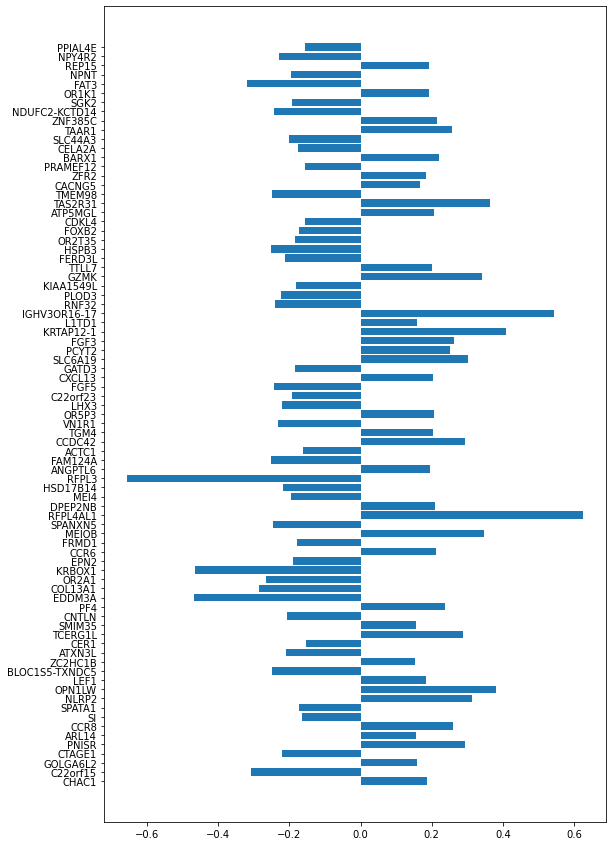

In [124]:
cutoff = 0.15
# lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state= 4242).fit(X_train, y_train)
lr_l1 = LogisticRegression( max_iter=10000,class_weight=None, dual=False, 
                           fit_intercept=True, intercept_scaling=1, l1_ratio=None, n_jobs=None, 
                           penalty='l1', random_state= 4242, solver='liblinear', tol=0.0001, verbose=0, 
                           warm_start=False).fit(X_train, y_train)
# print(lr_l1.coef_, lr_l1.intercept_)
# clf = SelectFromModel(lr_l1, threshold=1e-1, prefit=True)
clf = SelectFromModel(lr_l1, threshold = cutoff, prefit=True)

feature_idx = clf.get_support() 
feature_name = feature_names[feature_idx]

X_filtered  = clf.transform(X_train)

# r_l1 = LogisticRegression(C = LR_penalty.C, max_iter=10000,class_weight=None, dual=False, 
#                            fit_intercept=True, intercept_scaling=1, l1_ratio=None, n_jobs=None, 
#                            penalty='l1', random_state=None, solver='liblinear', tol=0.0001, verbose=0, 
#                            warm_start=False).fit(X_train, y_train)




# Plot
importance = lr_l1.coef_[0]
# for i,v in enumerate(importance):
#     if np.abs(v) >= cutoff:
#         print('Feature: %0d, Score: %.5f' % (i,v))
sel = importance[np.abs(importance) >= cutoff]
# plot feature importance

plt.figure(figsize=(9, 15))
plt.barh([x for x in feature_name], sel)
# plt.bar(sel, [x for x in feature_name])
# plt.xticks(fontsize=10, rotation=70)
# plt.ylabel('Feature Importance', fontsize = 14)
plt.show()

In [125]:
NuSVC_model = svm.NuSVC(nu=0.1, decision_function_shape='ovo', probability=True)
NuSVC_model.fit(X_filtered, y_train)


# Now predict on test data using the trained model. 

#First apply feature selector transform to make sure same features are selected from test data
X_test_filtered = clf.transform(X_test)
prediction_NuSVC = NuSVC_model.predict(X_test_filtered)


#Print overall accuracy

print ("Accuracy = ", metrics.accuracy_score(y_test, prediction_NuSVC))




Accuracy =  0.7092511013215859


In [126]:
#grid search for best parameter:
indexesC=np.arange(1,30,2)
searchScores=np.zeros(len(indexesC))
for i,c in enumerate(indexesC):
    model=svm.SVC(C = c, decision_function_shape='ovo', probability=True)
    model.fit(X_filtered, y_train)
    searchScores[i]=model.score(X_filtered, y_train)

print(searchScores)
print('bestScore:',np.max(searchScores))
print(np.argmax(searchScores))
bestC=indexesC[int(np.argmax(searchScores))]
print('best parameter:',bestC)

best_NuSVC_model = svm.SVC(C = bestC, decision_function_shape='ovo', probability=True)
best_NuSVC_model.fit(X_filtered, y_train)


best_prediction_NuSVC = best_NuSVC_model.predict(X_test_filtered)


#Print overall accuracy

print ("Accuracy = ", metrics.accuracy_score(y_test, best_prediction_NuSVC))



[0.99620493 0.99810247 1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.        ]
bestScore: 1.0
2
best parameter: 5
Accuracy =  0.7092511013215859


Accuracy =  0.7312775330396476


<Axes: >

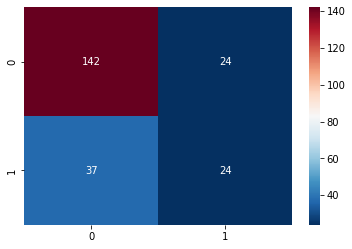

In [127]:
### SVM
svc_model = SVC(probability=True).fit(X_filtered, y_train)

prediction_svc = svc_model.predict(X_test_filtered)


#Print overall accuracy

print ("Accuracy = ", metrics.accuracy_score(y_test, prediction_svc))

#Confusion Matrix - verify accuracy of each class

cm = confusion_matrix(y_test, prediction_svc)
#print(cm)
sns.heatmap(cm, annot=True, cmap='RdBu_r', fmt='.3g')
# sns.heatmap(cm, annot=True, cmap=sns.diverging_palette(220, 20, as_cmap=True), fmt='.3g')
# sns.heatmap(cm, annot=True,  fmt='.3g')

Accuracy =  0.7400881057268722


<Axes: >

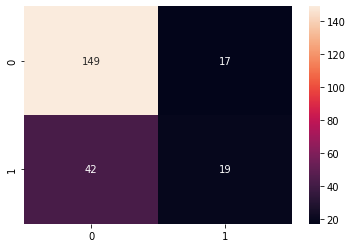

In [128]:

xgb_model = xgb.XGBClassifier()

xgb_model.fit(X_filtered, y_train)

#Now predict on test data using the trained model. 

#First apply feature selector transform to make sure same features are selected from test data
X_test_filtered = clf.transform(X_test)
prediction_xgb = xgb_model.predict(X_test_filtered)


#Print overall accuracy

print ("Accuracy = ", metrics.accuracy_score(y_test, prediction_xgb))

#Confusion Matrix - verify accuracy of each class

cm = confusion_matrix(y_test, prediction_xgb)
#print(cm)
sns.heatmap(cm, annot=True, fmt='.3g')

